<a href="https://colab.research.google.com/github/Kishoby/Conceptual-Research_Hybrid-Approach/blob/Temperature_Celsius/XAI_Temperature_Hybrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

!pip install river --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.


In [5]:

import pandas as pd
import numpy as np

from river import metrics, compose, preprocessing

print("River imported successfully")

River imported successfully


In [6]:

path = "/content/drive/MyDrive/Research v2/Research 18.03.2026/Temperature_Celsius/final_temperature_dataset.csv"
temp_df = pd.read_csv(path)

print("Dataset shape:", temp_df.shape)
temp_df.head()

Dataset shape: (130003, 16)


,uv_index,latitude,humidity,pressure_mb,air_quality_Ozone,condition_text,air_quality_Nitrogen_dioxide,cloud,visibility_km,longitude,air_quality_PM10,wind_mph,gust_mph,wind_degree,precip_mm,temperature_celsius
0,1.0,46.60,58,1012.0,62.2,2,2.5,0,16.0,-120.49,7.1,4.3,10.3,220,0.00,16.1
1,1.0,14.10,78,1017.0,23.3,32,3.7,37,10.0,-87.22,25.3,3.8,7.0,240,0.28,23.0
2,1.0,13.71,94,1010.0,5.9,23,7.7,50,10.0,-89.20,28.1,2.2,2.8,182,0.30,26.0
3,1.0,14.62,88,1019.0,0.4,19,35.0,100,5.0,-90.53,178.1,13.6,18.1,190,0.09,20.0
4,1.0,17.25,89,1007.0,34.0,30,0.3,94,10.0,-88.77,32.1,4.3,6.5,99,0.00,26.0


In [7]:
target = "temperature_celsius"

In [8]:



# -----------------------------
# TEMPERATURE LAG FEATURES
# -----------------------------
temp_df["temp_lag1"] = temp_df[target].shift(1)
temp_df["temp_lag2"] = temp_df[target].shift(2)
temp_df["temp_lag3"] = temp_df[target].shift(3)
temp_df["temp_lag5"] = temp_df[target].shift(5)
temp_df["temp_lag7"] = temp_df[target].shift(7)

# -----------------------------
# ROLLING FEATURES FOR TEMPERATURE
# -----------------------------
temp_df["temp_roll3_mean"] = temp_df[target].rolling(window=3).mean()
temp_df["temp_roll5_mean"] = temp_df[target].rolling(window=5).mean()
temp_df["temp_roll7_mean"] = temp_df[target].rolling(window=7).mean()

temp_df["temp_roll3_std"] = temp_df[target].rolling(window=3).std()
temp_df["temp_roll5_std"] = temp_df[target].rolling(window=5).std()

# -----------------------------
# RELATED WEATHER FEATURE LAGS
# -----------------------------
if "humidity" in temp_df.columns:
    temp_df["humidity_lag1"] = temp_df["humidity"].shift(1)
    temp_df["humidity_lag3"] = temp_df["humidity"].shift(3)

if "pressure_mb" in temp_df.columns:
    temp_df["pressure_lag1"] = temp_df["pressure_mb"].shift(1)
    temp_df["pressure_lag3"] = temp_df["pressure_mb"].shift(3)

if "wind_mph" in temp_df.columns:
    temp_df["wind_lag1"] = temp_df["wind_mph"].shift(1)
    temp_df["wind_lag3"] = temp_df["wind_mph"].shift(3)

if "gust_mph" in temp_df.columns:
    temp_df["gust_lag1"] = temp_df["gust_mph"].shift(1)

if "cloud" in temp_df.columns:
    temp_df["cloud_lag1"] = temp_df["cloud"].shift(1)

if "precip_mm" in temp_df.columns:
    temp_df["precip_lag1"] = temp_df["precip_mm"].shift(1)

# -----------------------------
# INTERACTION FEATURES
# -----------------------------
if "humidity" in temp_df.columns:
    temp_df["humidity_temp_interaction"] = temp_df["humidity"] * temp_df[target]

if "wind_mph" in temp_df.columns and "cloud" in temp_df.columns:
    temp_df["wind_cloud_interaction"] = temp_df["wind_mph"] * temp_df["cloud"]

if "pressure_mb" in temp_df.columns and "humidity" in temp_df.columns:
    temp_df["pressure_humidity_interaction"] = temp_df["pressure_mb"] * temp_df["humidity"]

# -----------------------------
# REMOVE NA CREATED BY LAGS
# -----------------------------
temp_df = temp_df.dropna().reset_index(drop=True)

print("After feature engineering:", temp_df.shape)
temp_df.head()


After feature engineering: (129996, 38)


,uv_index,latitude,humidity,pressure_mb,air_quality_Ozone,condition_text,air_quality_Nitrogen_dioxide,cloud,visibility_km,longitude,...,pressure_lag1,pressure_lag3,wind_lag1,wind_lag3,gust_lag1,cloud_lag1,precip_lag1,humidity_temp_interaction,wind_cloud_interaction,pressure_humidity_interaction
0,1.0,19.43,47,1013.0,7.4,2,48.7,5,10.0,-99.13,...,1016.0,1007.0,2.2,4.3,3.8,75.0,0.17,977.6,33.5,47611.0
1,1.0,17.97,84,1013.0,0.2,41,12.2,84,10.0,-76.75,...,1013.0,1009.0,6.7,3.6,7.7,5.0,0.00,1839.6,184.8,85092.0
2,1.0,8.97,94,1010.0,11.6,30,8.7,100,10.0,-79.53,...,1013.0,1016.0,2.2,2.2,2.8,84.0,0.10,2444.0,220.0,94940.0
3,1.0,-0.22,92,1016.0,0.0,41,72.7,76,10.0,-78.50,...,1010.0,1013.0,2.2,6.7,8.3,100.0,0.06,1094.8,205.2,93472.0
4,1.0,-12.05,89,1013.0,30.0,31,12.2,59,10.0,-77.05,...,1016.0,1013.0,2.7,2.2,3.8,76.0,0.03,1477.4,436.6,90157.0


In [9]:

selected_features = [col for col in temp_df.columns if col != target]

print("Number of features:", len(selected_features))
print(selected_features)

Number of features: 37
['uv_index', 'latitude', 'humidity', 'pressure_mb', 'air_quality_Ozone', 'condition_text', 'air_quality_Nitrogen_dioxide', 'cloud', 'visibility_km', 'longitude', 'air_quality_PM10', 'wind_mph', 'gust_mph', 'wind_degree', 'precip_mm', 'temp_lag1', 'temp_lag2', 'temp_lag3', 'temp_lag5', 'temp_lag7', 'temp_roll3_mean', 'temp_roll5_mean', 'temp_roll7_mean', 'temp_roll3_std', 'temp_roll5_std', 'humidity_lag1', 'humidity_lag3', 'pressure_lag1', 'pressure_lag3', 'wind_lag1', 'wind_lag3', 'gust_lag1', 'cloud_lag1', 'precip_lag1', 'humidity_temp_interaction', 'wind_cloud_interaction', 'pressure_humidity_interaction']


In [10]:
split_index = int(0.8 * len(temp_df))

train_df = temp_df.iloc[:split_index].copy()
test_df = temp_df.iloc[split_index:].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (103996, 38)
Test shape : (26000, 38)


In [11]:
n_train = len(train_df)

iter1 = train_df.iloc[:int(0.33 * n_train)].copy()
iter2 = train_df.iloc[int(0.33 * n_train):int(0.66 * n_train)].copy()
iter3 = train_df.iloc[int(0.66 * n_train):].copy()

print("Iteration 1 shape:", iter1.shape)
print("Iteration 2 shape:", iter2.shape)
print("Iteration 3 shape:", iter3.shape)

Iteration 1 shape: (34318, 38)
Iteration 2 shape: (34319, 38)
Iteration 3 shape: (35359, 38)


In [12]:
try:
    from river import forest

    river_model = forest.ARFRegressor(
        n_models=20,
        max_features="sqrt",
        lambda_value=6,
        seed=42
    )
    model_name = "River ARF Hybrid"

except Exception:
    from river import tree

    river_model = compose.Pipeline(
        preprocessing.StandardScaler(),
        tree.HoeffdingAdaptiveTreeRegressor(
            grace_period=50,
            delta=1e-5,
            leaf_prediction="adaptive"
        )
    )
    model_name = "River HAT Hybrid"

print("Using model:", model_name)

Using model: River ARF Hybrid


In [13]:
def run_hybrid_iteration(data, model, iteration_name, selected_features, target, warmup=False):
    mse = metrics.MSE()
    rmse = metrics.RMSE()
    mae = metrics.MAE()
    r2 = metrics.R2()

    y_true_all = []
    y_pred_all = []

    first_part = int(0.1 * len(data)) if warmup else 0

    for i, (_, row) in enumerate(data.iterrows()):
        x = row[selected_features].to_dict()
        y = row[target]

        if i < first_part:
            model.learn_one(x, y)
            continue

        y_pred = model.predict_one(x)
        if y_pred is None:
            y_pred = 0.0

        y_true_all.append(y)
        y_pred_all.append(y_pred)

        mse.update(y, y_pred)
        rmse.update(y, y_pred)
        mae.update(y, y_pred)
        r2.update(y, y_pred)

        model.learn_one(x, y)

    print(f"\n{iteration_name}")
    print("MSE :", round(mse.get(), 4))
    print("RMSE:", round(rmse.get(), 4))
    print("MAE :", round(mae.get(), 4))
    print("R2  :", round(r2.get(), 4))
    print("Accuracy (%):", round(r2.get() * 100, 2))

    return model, mse.get(), rmse.get(), mae.get(), r2.get(), y_true_all, y_pred_all

In [15]:

river_results = []

river_model, mse1, rmse1, mae1, r21, y_true1, y_pred1 = run_hybrid_iteration(
    iter1, river_model, "Iteration 1", selected_features, target, warmup=True
)

river_results.append([
    "Iteration 1", model_name, mse1, rmse1, mae1, r21, r21 * 100
])



Iteration 1
MSE : 5.2986
RMSE: 2.3019
MAE : 1.6857
R2  : 0.9047
Accuracy (%): 90.47


In [16]:
river_model, mse2, rmse2, mae2, r22, y_true2, y_pred2 = run_hybrid_iteration(
    iter2, river_model, "Iteration 2", selected_features, target, warmup=False
)

river_results.append([
    "Iteration 2", model_name, mse2, rmse2, mae2, r22, r22 * 100
])


Iteration 2
MSE : 11.9486
RMSE: 3.4567
MAE : 2.4003
R2  : 0.8867
Accuracy (%): 88.67


In [18]:
river_model, mse3, rmse3, mae3, r23, y_true3, y_pred3 = run_hybrid_iteration(
    iter3, river_model, "Iteration 3", selected_features, target, warmup=False
)

river_results.append([
    "Iteration 3", model_name, mse3, rmse3, mae3, r23, r23 * 100
])


Iteration 3
MSE : 5.4792
RMSE: 2.3408
MAE : 1.7462
R2  : 0.8992
Accuracy (%): 89.92


In [19]:
river_results_df = pd.DataFrame(
    river_results,
    columns=["Iteration", "Model", "MSE", "RMSE", "MAE", "R2", "Accuracy (%)"]
).round(3)

river_results_df

,Iteration,Model,MSE,RMSE,MAE,R2,Accuracy (%)
0,Iteration 1,River ARF Hybrid,5.299,2.302,1.686,0.905,90.471
1,Iteration 2,River ARF Hybrid,11.949,3.457,2.400,0.887,88.668
2,Iteration 3,River ARF Hybrid,5.479,2.341,1.746,0.899,89.923


In [20]:
test_mse = metrics.MSE()
test_rmse = metrics.RMSE()
test_mae = metrics.MAE()
test_r2 = metrics.R2()

test_true = []
test_pred = []

for _, row in test_df.iterrows():
    x = row[selected_features].to_dict()
    y = row[target]

    y_hat = river_model.predict_one(x)
    if y_hat is None:
        y_hat = 0.0

    test_true.append(y)
    test_pred.append(y_hat)

    test_mse.update(y, y_hat)
    test_rmse.update(y, y_hat)
    test_mae.update(y, y_hat)
    test_r2.update(y, y_hat)

print("\nFinal Test Performance")
print("MSE :", round(test_mse.get(), 4))
print("RMSE:", round(test_rmse.get(), 4))
print("MAE :", round(test_mae.get(), 4))
print("R2  :", round(test_r2.get(), 4))
print("Accuracy (%):", round(test_r2.get() * 100, 2))


Final Test Performance
MSE : 15.5215
RMSE: 3.9397
MAE : 2.5498
R2  : 0.875
Accuracy (%): 87.5


In [21]:

river_final_test_df = pd.DataFrame([{
    "Model": model_name,
    "MSE": round(test_mse.get(), 3),
    "RMSE": round(test_rmse.get(), 3),
    "MAE": round(test_mae.get(), 3),
    "R2": round(test_r2.get(), 3),
    "Accuracy (%)": round(test_r2.get() * 100, 3)
}])

river_final_test_df

,Model,MSE,RMSE,MAE,R2,Accuracy (%)
0,River ARF Hybrid,15.522,3.94,2.55,0.875,87.503


In [22]:
import os
import pickle
import pandas as pd

save_path = "/content/drive/MyDrive/Hybrid_XAI_Data"
os.makedirs(save_path, exist_ok=True)

# Save feature matrices
iter1[selected_features].to_csv(f"{save_path}/X_iter1.csv", index=False)
iter2[selected_features].to_csv(f"{save_path}/X_iter2.csv", index=False)
iter3[selected_features].to_csv(f"{save_path}/X_iter3.csv", index=False)

# Save hybrid predictions
pd.Series(y_pred1).to_csv(f"{save_path}/y_pred1.csv", index=False)
pd.Series(y_pred2).to_csv(f"{save_path}/y_pred2.csv", index=False)
pd.Series(y_pred3).to_csv(f"{save_path}/y_pred3.csv", index=False)

# Save feature list
with open(f"{save_path}/selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

print("Hybrid data saved successfully.")

Hybrid data saved successfully.


In [23]:
import pickle
import pandas as pd

save_path = "/content/drive/MyDrive/Hybrid_XAI_Data"

X1 = pd.read_csv(f"{save_path}/X_iter1.csv")
X2 = pd.read_csv(f"{save_path}/X_iter2.csv")
X3 = pd.read_csv(f"{save_path}/X_iter3.csv")

y_pred1 = pd.read_csv(f"{save_path}/y_pred1.csv").iloc[:, 0]
y_pred2 = pd.read_csv(f"{save_path}/y_pred2.csv").iloc[:, 0]
y_pred3 = pd.read_csv(f"{save_path}/y_pred3.csv").iloc[:, 0]

with open(f"{save_path}/selected_features.pkl", "rb") as f:
    selected_features = pickle.load(f)

print("Saved hybrid data loaded successfully.")

Saved hybrid data loaded successfully.


In [24]:
import numpy
print(numpy.__version__)

2.0.2


In [25]:
!pip uninstall -y numpy numba shap llvmlite

Found existing installation: numpy 2.5.1
Uninstalling numpy-2.5.1:
  Successfully uninstalled numpy-2.5.1
Found existing installation: numba 0.60.0
Uninstalling numba-0.60.0:
  Successfully uninstalled numba-0.60.0
Found existing installation: shap 0.46.0
Uninstalling shap-0.46.0:
  Successfully uninstalled shap-0.46.0
Found existing installation: llvmlite 0.43.0
Uninstalling llvmlite-0.43.0:
  Successfully uninstalled llvmlite-0.43.0


In [26]:
!pip install numpy==2.0.2
!pip install numba==0.60.0
!pip install llvmlite==0.43.0
!pip install shap==0.46.0

  Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, which is not installed.
segregation 2.5.4 requires numba, which is not installed.
stumpy 1.13.0 requires numba>=0.57.1, which is not installed.
librosa 0.11.0 requires numba>=0.51.0, which is not installed.
pynndescent 0.6.0 requires llvmlite>=0.38, which is not installed.
pynndescent 0.6.0 requires numba>=0.55.0, which is not installed.
umap-learn 0.5.12 requires numba>=0.51.2, which is not installed.
quantecon 0.11.2 requires numba>=0.49.0, which is not installed.
river 0.25.0 requires numpy<3,>=2.3.4, but you have numpy 2.0.2 which is incompatible.


  Using cached numba-0.60.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.7 kB)
  Using cached llvmlite-0.43.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.8 kB)
Using cached numba-0.60.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.8 MB)
Using cached llvmlite-0.43.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (43.9 MB)


  Using cached shap-0.46.0-cp312-cp312-manylinux_2_12_x86_64.manylinux2010_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (24 kB)
Using cached shap-0.46.0-cp312-cp312-manylinux_2_12_x86_64.manylinux2010_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl (543 kB)


In [27]:
import numpy
import numba
import shap

print("NumPy :", numpy.__version__)
print("Numba :", numba.__version__)
print("SHAP :", shap.__version__)

NumPy : 2.0.2
Numba : 0.60.0
SHAP : 0.46.0


In [28]:
# ============================================================
# TEMPERATURE HYBRID MODEL SURROGATE EXPLAINABLE AI
# Target: temperature_celsius
# Method: Surrogate Random Forest + SHAP + Feature Monitoring
# ============================================================

import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from google.colab import files
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

shap.initjs()

save_dir = "/content/Temperature_Hybrid_Surrogate_XAI_Outputs"
os.makedirs(save_dir, exist_ok=True)

target = "temperature_celsius"

def safe_name(name):
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(name))


# ============================================================
# 1. Prepare Data for Surrogate Model
# ============================================================

X1 = iter1[selected_features].copy()
X2 = iter2[selected_features].copy()
X3 = iter3[selected_features].copy()

y_pred1 = np.array(y_pred1)
y_pred2 = np.array(y_pred2)
y_pred3 = np.array(y_pred3)

# Iteration 1 has warmup=True, so y_pred1 is shorter than X1
X1 = X1.iloc[-len(y_pred1):].reset_index(drop=True)
X2 = X2.iloc[-len(y_pred2):].reset_index(drop=True)
X3 = X3.iloc[-len(y_pred3):].reset_index(drop=True)

y_pred1 = pd.Series(y_pred1).reset_index(drop=True)
y_pred2 = pd.Series(y_pred2).reset_index(drop=True)
y_pred3 = pd.Series(y_pred3).reset_index(drop=True)

surrogate_data = {
    "Iteration 1": {
        "X": X1,
        "Hybrid_Prediction": y_pred1
    },
    "Iteration 2": {
        "X": X2,
        "Hybrid_Prediction": y_pred2
    },
    "Iteration 3": {
        "X": X3,
        "Hybrid_Prediction": y_pred3
    }
}

print("Temperature surrogate data prepared")
print("Iteration 1:", X1.shape, y_pred1.shape)
print("Iteration 2:", X2.shape, y_pred2.shape)
print("Iteration 3:", X3.shape, y_pred3.shape)

Temperature surrogate data prepared
Iteration 1: (30887, 37) (30887,)
Iteration 2: (34319, 37) (34319,)
Iteration 3: (35359, 37) (35359,)


In [29]:
# ============================================================
# 2. Train Surrogate Random Forest Models
# ============================================================

surrogate_models = {}
surrogate_fidelity_results = []
all_feature_importance = []

for iteration_name, data in surrogate_data.items():

    X = data["X"]
    y_hybrid = data["Hybrid_Prediction"]

    sample_size = min(10000, len(X))

    X_sample = X.sample(sample_size, random_state=42)
    y_sample = y_hybrid.loc[X_sample.index]

    surrogate_model = RandomForestRegressor(
        n_estimators=150,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )

    surrogate_model.fit(X_sample, y_sample)

    surrogate_pred = surrogate_model.predict(X_sample)

    fidelity_r2 = r2_score(y_sample, surrogate_pred)
    fidelity_rmse = np.sqrt(mean_squared_error(y_sample, surrogate_pred))
    fidelity_mae = mean_absolute_error(y_sample, surrogate_pred)

    surrogate_models[iteration_name] = {
        "model": surrogate_model,
        "X_sample": X_sample,
        "y_sample": y_sample,
        "surrogate_pred": surrogate_pred
    }

    surrogate_fidelity_results.append({
        "Iteration": iteration_name,
        "Fidelity_R2": fidelity_r2,
        "Fidelity_RMSE": fidelity_rmse,
        "Fidelity_MAE": fidelity_mae
    })

    fi_df = pd.DataFrame({
        "Iteration": iteration_name,
        "Feature": X_sample.columns,
        "Importance": surrogate_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    all_feature_importance.append(fi_df)

surrogate_fidelity_df = pd.DataFrame(surrogate_fidelity_results).round(4)
feature_importance_df = pd.concat(all_feature_importance, ignore_index=True)

surrogate_fidelity_df.to_csv(
    f"{save_dir}/Temperature_Surrogate_Fidelity_Results.csv",
    index=False
)

feature_importance_df.to_csv(
    f"{save_dir}/Temperature_Surrogate_Feature_Importance_All_Iterations.csv",
    index=False
)

print("Surrogate Fidelity Results")
display(surrogate_fidelity_df)

print("Top Feature Importance")
display(feature_importance_df.head(20))

Surrogate Fidelity Results


,Iteration,Fidelity_R2,Fidelity_RMSE,Fidelity_MAE
0,Iteration 1,0.9693,1.0500,0.7922
1,Iteration 2,0.9687,1.4345,1.0756
2,Iteration 3,0.9682,1.1303,0.8544


Top Feature Importance


,Iteration,Feature,Importance
0,Iteration 1,uv_index,0.437261
1,Iteration 1,humidity_temp_interaction,0.231090
2,Iteration 1,temp_roll3_mean,0.146784
3,Iteration 1,latitude,0.071788
4,Iteration 1,pressure_humidity_interaction,0.045674
5,Iteration 1,pressure_mb,0.031645
6,Iteration 1,longitude,0.009295
7,Iteration 1,temp_roll3_std,0.004870
8,Iteration 1,temp_roll5_mean,0.004769
9,Iteration 1,humidity,0.004715


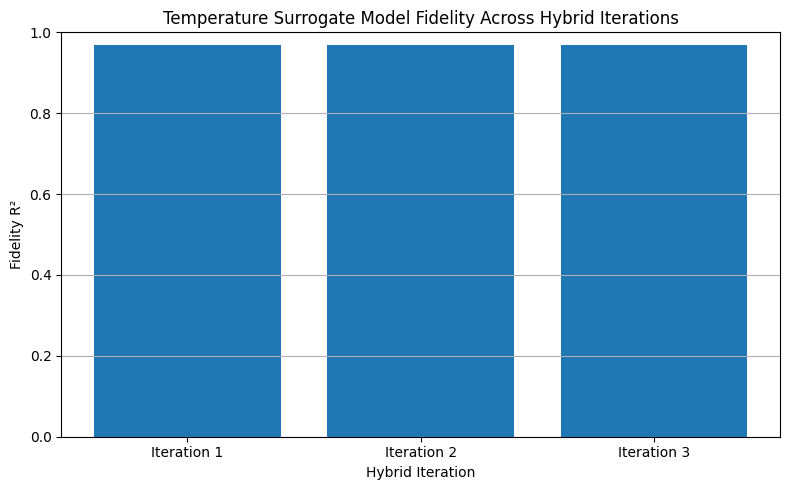

In [30]:
# ============================================================
# 3. Surrogate Fidelity Plot
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    surrogate_fidelity_df["Iteration"],
    surrogate_fidelity_df["Fidelity_R2"]
)

plt.title("Temperature Surrogate Model Fidelity Across Hybrid Iterations")
plt.xlabel("Hybrid Iteration")
plt.ylabel("Fidelity R²")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/01_Temperature_Surrogate_Fidelity_R2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

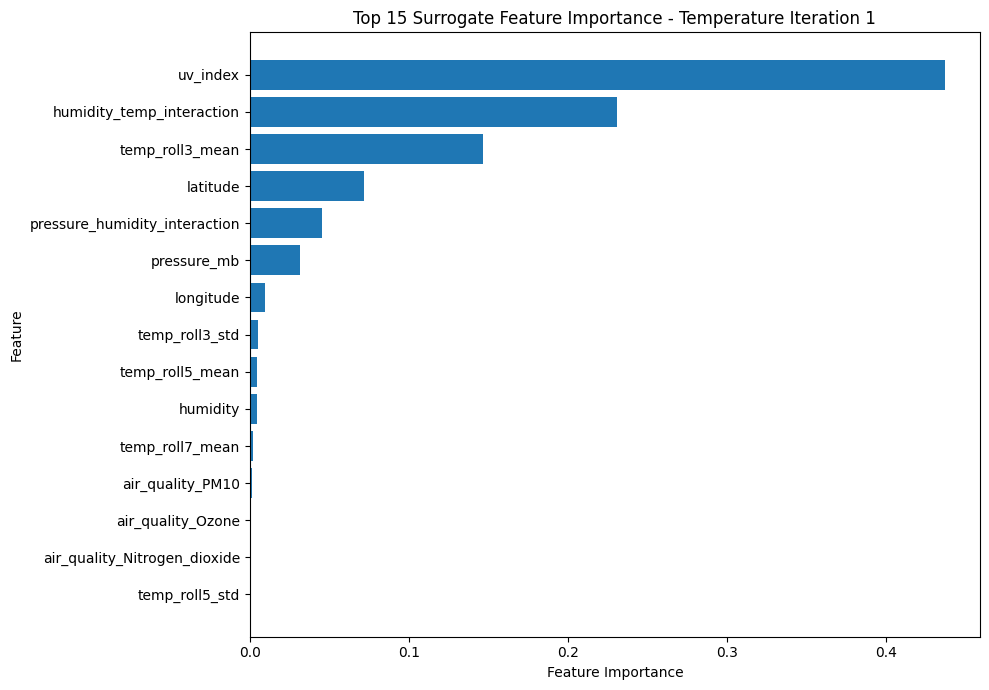

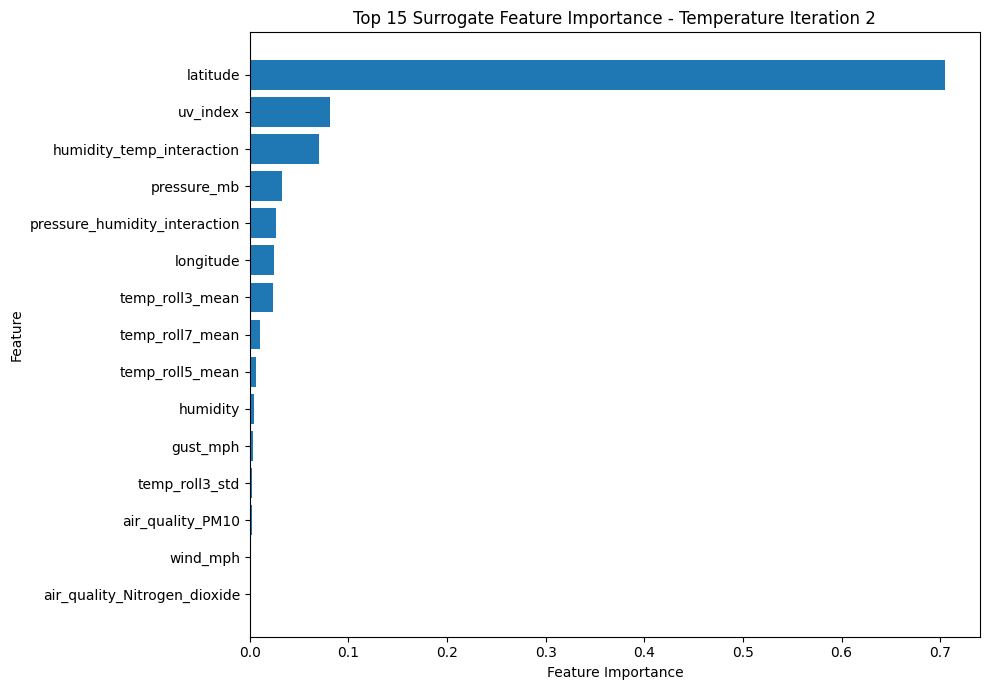

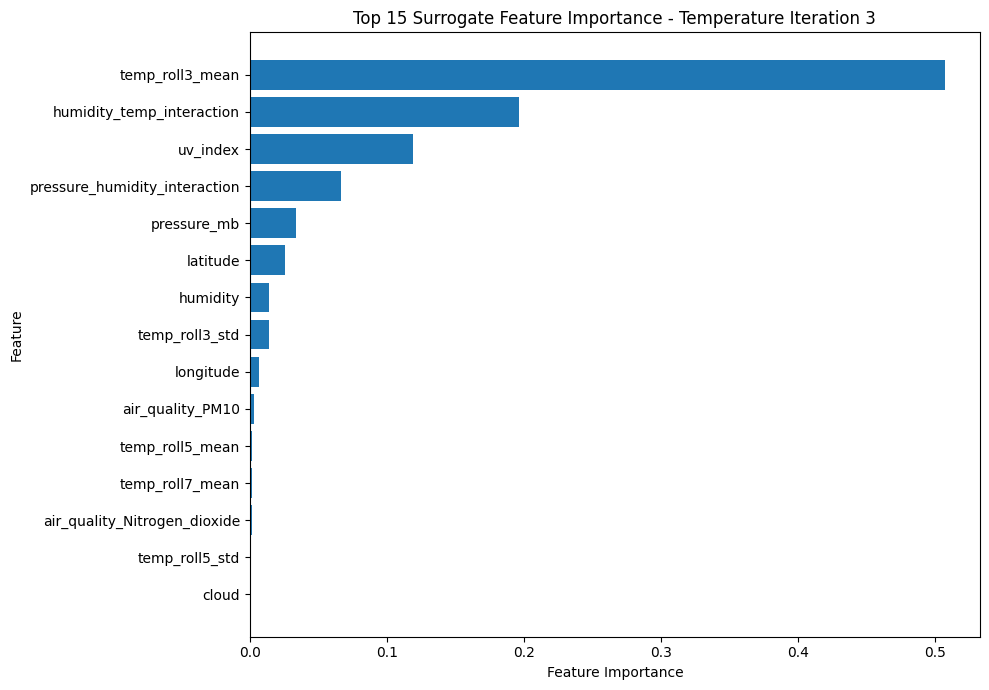

In [31]:
# ============================================================
# 4. Feature Importance Plot for Each Iteration
# ============================================================

for iteration_name in surrogate_data.keys():

    fi_iter = feature_importance_df[
        feature_importance_df["Iteration"] == iteration_name
    ].sort_values(by="Importance", ascending=False).head(15)

    plt.figure(figsize=(10,7))

    plt.barh(
        fi_iter["Feature"][::-1],
        fi_iter["Importance"][::-1]
    )

    plt.title(f"Top 15 Surrogate Feature Importance - Temperature {iteration_name}")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/02_Temperature_Feature_Importance_{safe_name(iteration_name)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

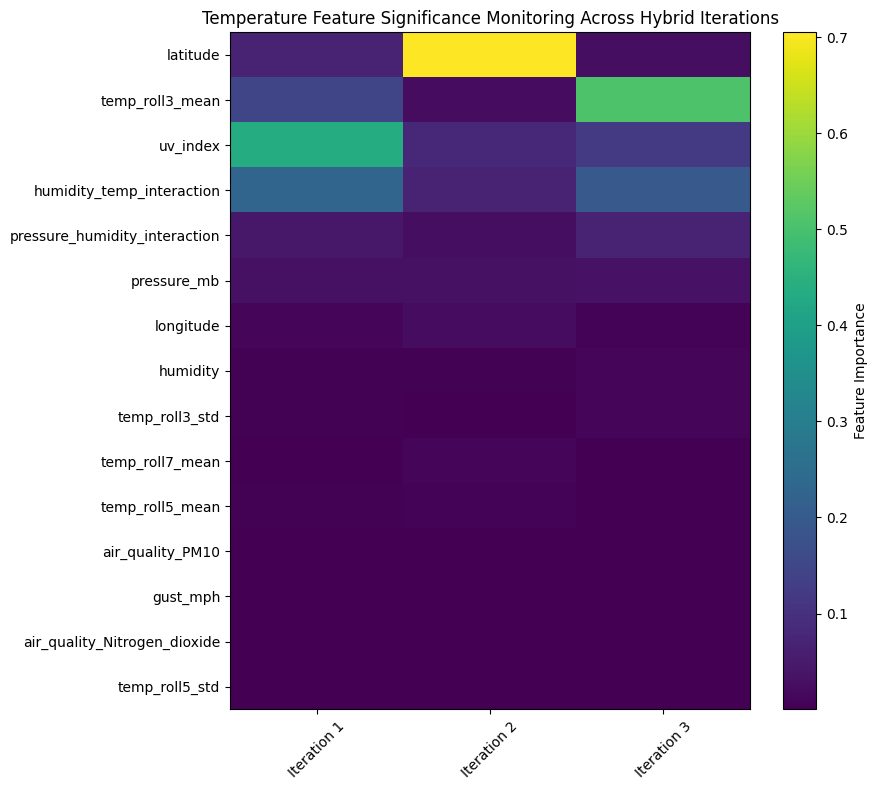

In [32]:
# ============================================================
# 5. Feature Significance Monitoring Heatmap
# ============================================================

top_features = (
    feature_importance_df
    .groupby("Feature")["Importance"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .index
)

monitor_df = feature_importance_df[
    feature_importance_df["Feature"].isin(top_features)
].pivot(
    index="Feature",
    columns="Iteration",
    values="Importance"
).fillna(0)

monitor_df = monitor_df.loc[top_features]

monitor_df.to_csv(
    f"{save_dir}/Temperature_Feature_Significance_Monitoring_Table.csv"
)

plt.figure(figsize=(9,8))

plt.imshow(monitor_df.values, aspect="auto")

plt.xticks(
    ticks=np.arange(len(monitor_df.columns)),
    labels=monitor_df.columns,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(monitor_df.index)),
    labels=monitor_df.index
)

plt.colorbar(label="Feature Importance")
plt.title("Temperature Feature Significance Monitoring Across Hybrid Iterations")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/03_Temperature_Feature_Significance_Monitoring_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

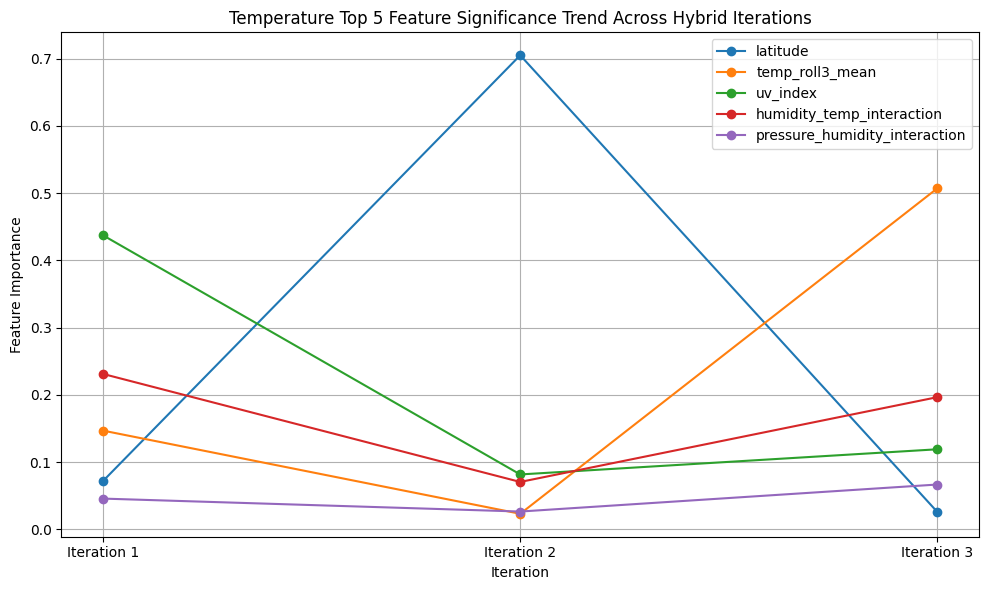

In [33]:
# ============================================================
# 6. Top 5 Feature Importance Trend
# ============================================================

top5_features = (
    feature_importance_df
    .groupby("Feature")["Importance"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

trend_df = feature_importance_df[
    feature_importance_df["Feature"].isin(top5_features)
].pivot(
    index="Iteration",
    columns="Feature",
    values="Importance"
).fillna(0)

trend_df.to_csv(
    f"{save_dir}/Temperature_Top5_Feature_Importance_Trend_Table.csv"
)

plt.figure(figsize=(10,6))

for feature in top5_features:
    plt.plot(
        trend_df.index,
        trend_df[feature],
        marker="o",
        label=feature
    )

plt.title("Temperature Top 5 Feature Significance Trend Across Hybrid Iterations")
plt.xlabel("Iteration")
plt.ylabel("Feature Importance")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/04_Temperature_Top5_Feature_Importance_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

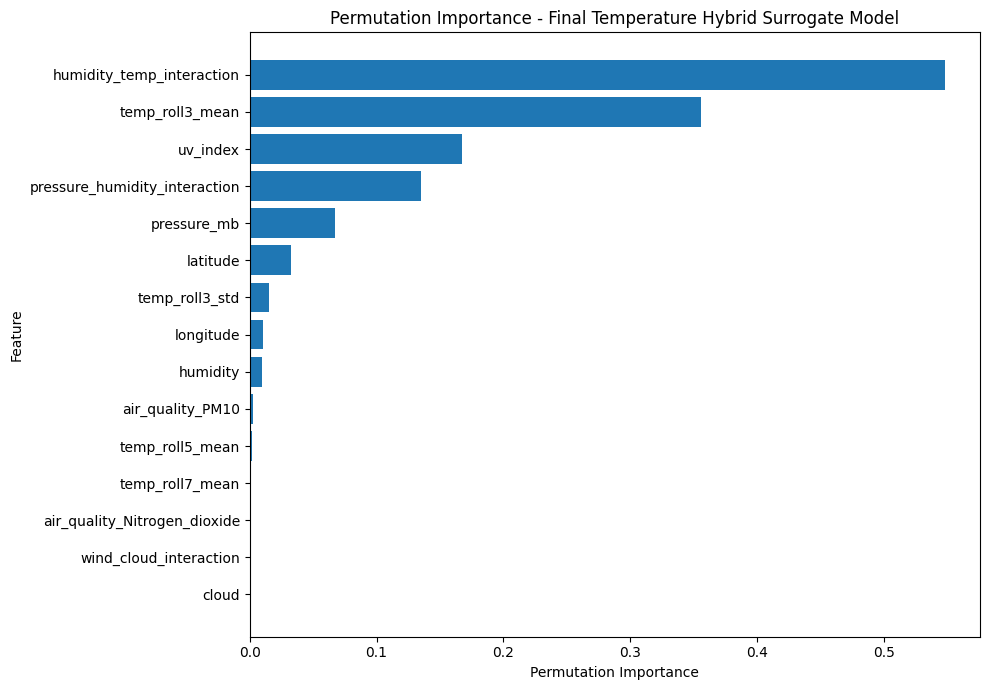

,Feature,Permutation_Importance
34,humidity_temp_interaction,0.548311
20,temp_roll3_mean,0.355652
0,uv_index,0.167007
36,pressure_humidity_interaction,0.134828
3,pressure_mb,0.067165
1,latitude,0.032772
23,temp_roll3_std,0.015500
9,longitude,0.010352
2,humidity,0.009655
10,air_quality_PM10,0.002529


In [34]:
# ============================================================
# 7. Permutation Importance for Final Surrogate
# ============================================================

final_iteration = "Iteration 3"

final_surrogate = surrogate_models[final_iteration]["model"]
X_final = surrogate_models[final_iteration]["X_sample"]
y_final = surrogate_models[final_iteration]["y_sample"]

perm_result = permutation_importance(
    final_surrogate,
    X_final,
    y_final,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_final.columns,
    "Permutation_Importance": perm_result.importances_mean
}).sort_values(by="Permutation_Importance", ascending=False)

perm_df.to_csv(
    f"{save_dir}/Temperature_Final_Iteration_Permutation_Importance.csv",
    index=False
)

top_perm = perm_df.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_perm["Feature"][::-1],
    top_perm["Permutation_Importance"][::-1]
)

plt.title("Permutation Importance - Final Temperature Hybrid Surrogate Model")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/05_Temperature_Final_Permutation_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

display(perm_df.head(20))

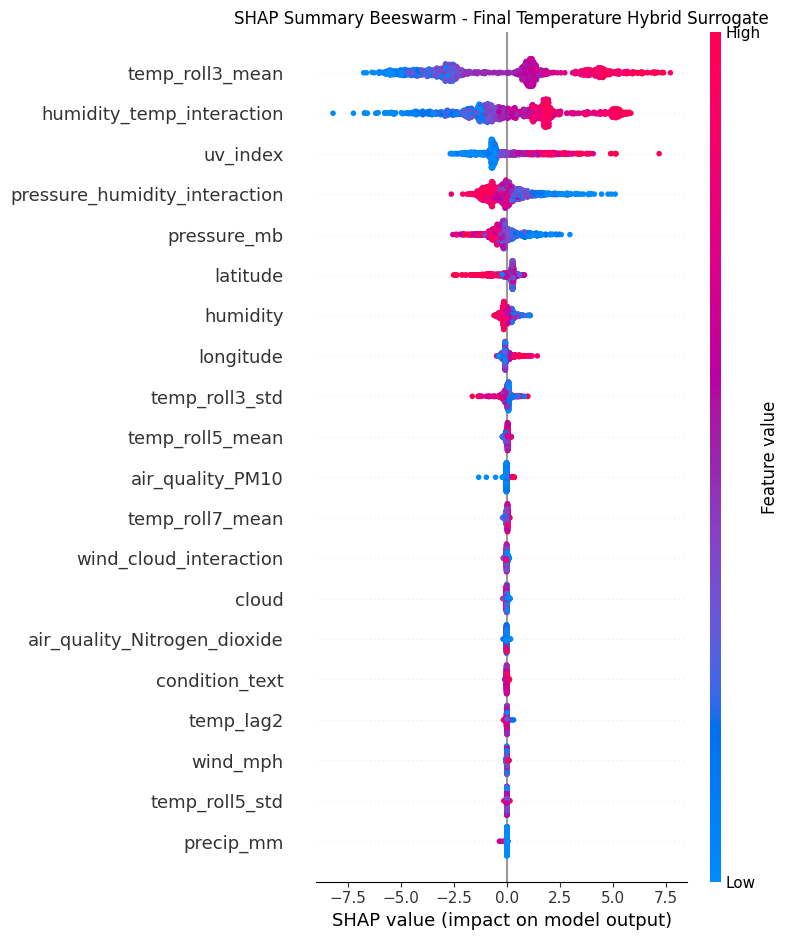

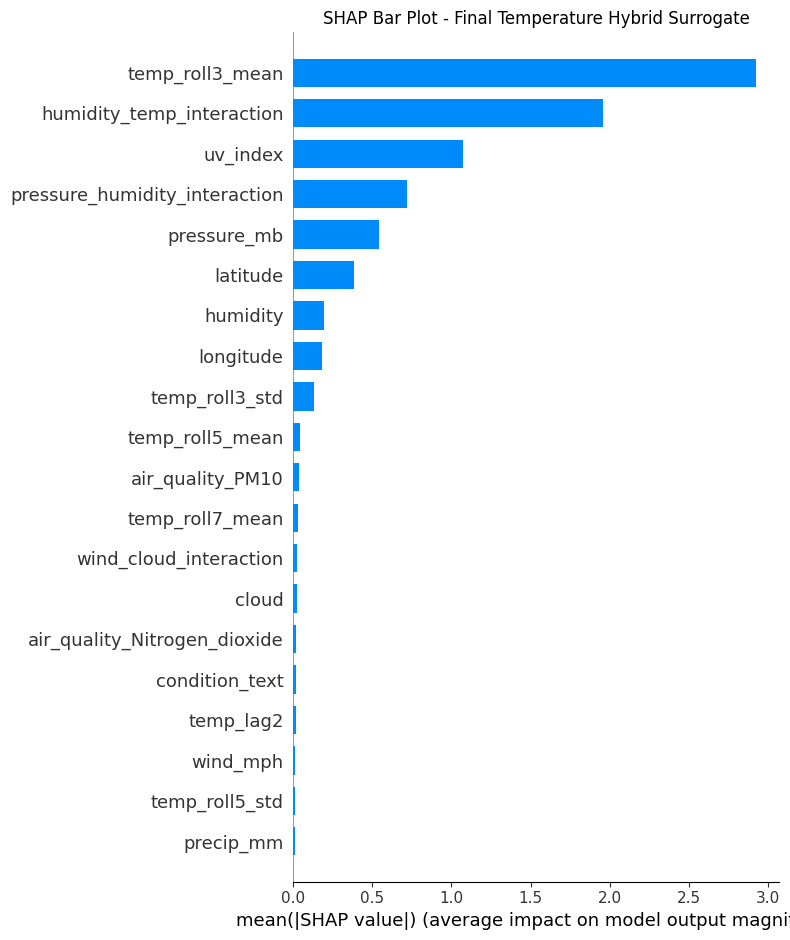

In [35]:
# ============================================================
# 8. SHAP Explainability for Final Surrogate
# ============================================================

X_shap = X_final.sample(
    min(1000, len(X_final)),
    random_state=42
)

explainer = shap.TreeExplainer(final_surrogate)
shap_values = explainer.shap_values(X_shap)

# SHAP Summary Beeswarm

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X_shap.columns,
    show=False
)

plt.title("SHAP Summary Beeswarm - Final Temperature Hybrid Surrogate")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/06_Temperature_SHAP_Summary_Beeswarm_Final_Surrogate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# SHAP Bar Plot

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X_shap.columns,
    plot_type="bar",
    show=False
)

plt.title("SHAP Bar Plot - Final Temperature Hybrid Surrogate")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/07_Temperature_SHAP_Bar_Final_Surrogate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

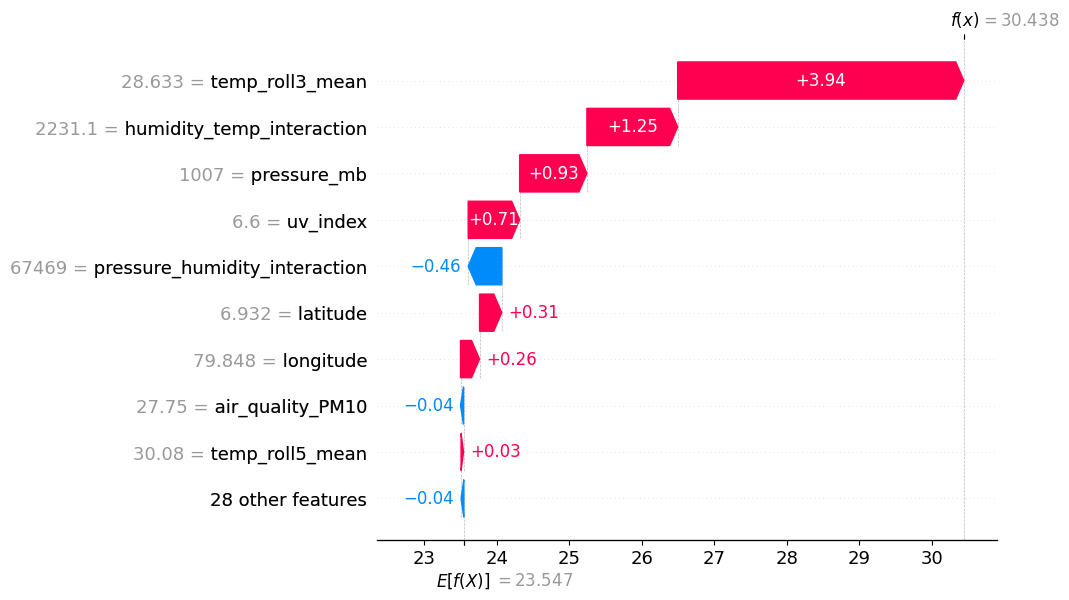

In [36]:
# ============================================================
# 9. SHAP Waterfall Plot
# ============================================================

sample_index = 0

explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_shap.iloc[sample_index],
    feature_names=X_shap.columns
)

shap.plots.waterfall(
    explanation,
    show=False
)

plt.savefig(
    f"{save_dir}/08_Temperature_SHAP_Waterfall_Final_Surrogate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

Top 3 SHAP Features:
['temp_roll3_mean', 'humidity_temp_interaction', 'uv_index']


,Feature,Mean_ABS_SHAP
20,temp_roll3_mean,2.923812
34,humidity_temp_interaction,1.959246
0,uv_index,1.074250
36,pressure_humidity_interaction,0.717791
3,pressure_mb,0.540019
1,latitude,0.383755
2,humidity,0.197347
9,longitude,0.183772
23,temp_roll3_std,0.128311
21,temp_roll5_mean,0.043820


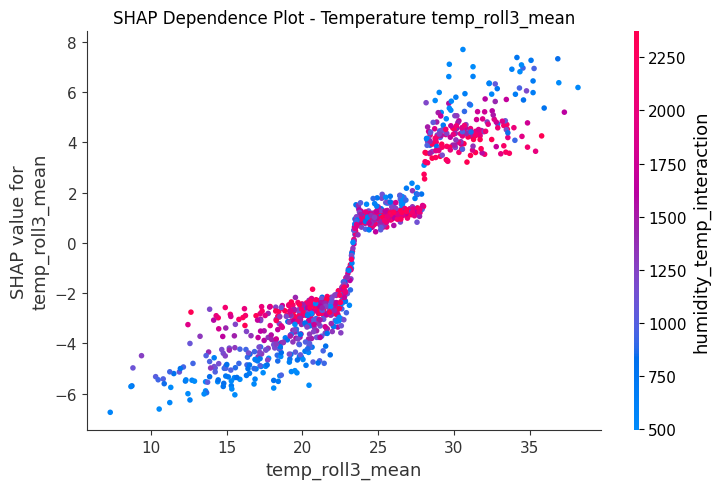

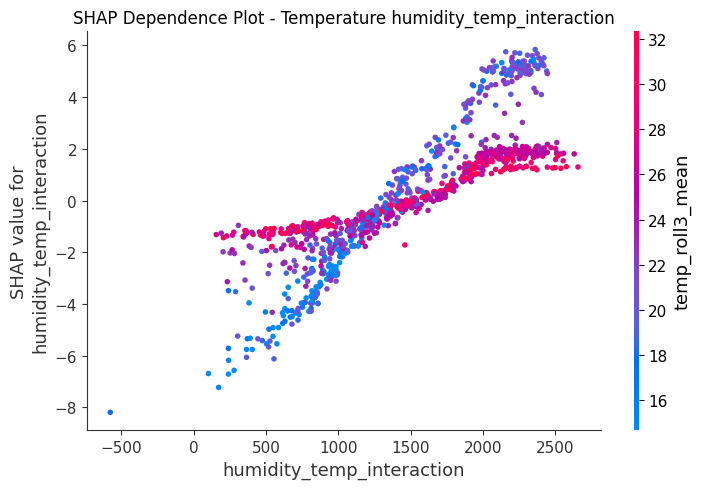

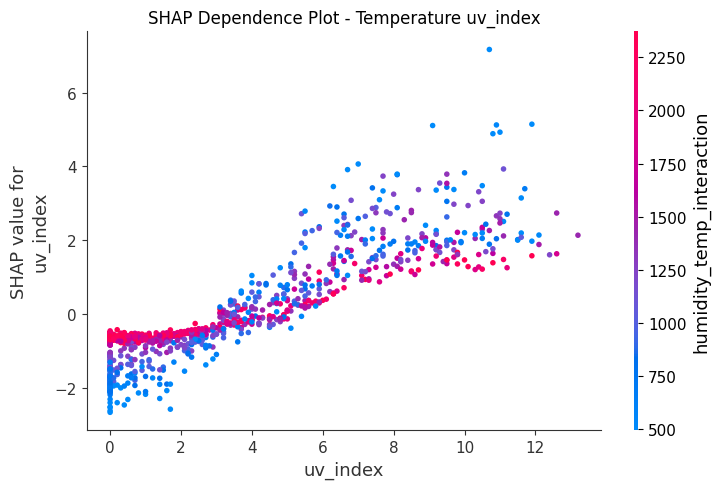

In [37]:
# ============================================================
# 10. SHAP Dependence Plots - Top 3 Features
# ============================================================

shap_importance = np.abs(shap_values).mean(axis=0)

top3_shap_features = X_shap.columns[
    np.argsort(shap_importance)[::-1][:3]
]

top_shap_df = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_ABS_SHAP": shap_importance
}).sort_values(by="Mean_ABS_SHAP", ascending=False)

top_shap_df.to_csv(
    f"{save_dir}/Temperature_SHAP_Feature_Importance.csv",
    index=False
)

print("Top 3 SHAP Features:")
print(list(top3_shap_features))

display(top_shap_df.head(15))

for feature in top3_shap_features:

    shap.dependence_plot(
        feature,
        shap_values,
        X_shap,
        interaction_index="auto",
        show=False
    )

    plt.title(f"SHAP Dependence Plot - Temperature {feature}")
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/09_Temperature_SHAP_Dependence_{safe_name(feature)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

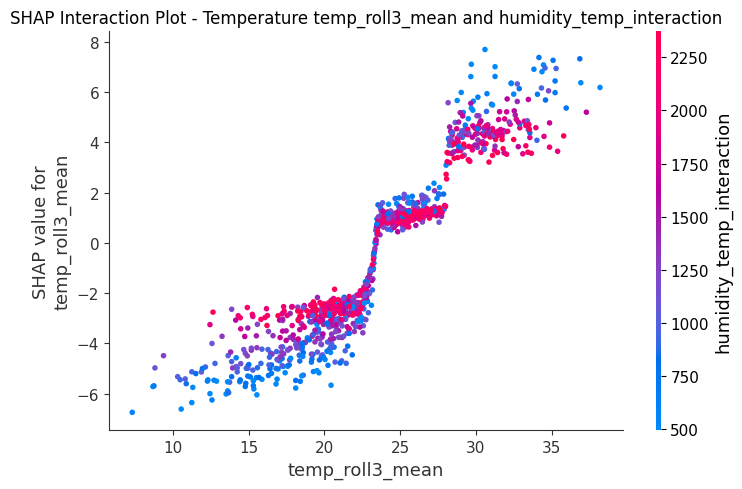

In [38]:
# ============================================================
# 11. SHAP Interaction Plot
# ============================================================

feature1 = top3_shap_features[0]
feature2 = top3_shap_features[1]

shap.dependence_plot(
    feature1,
    shap_values,
    X_shap,
    interaction_index=feature2,
    show=False
)

plt.title(f"SHAP Interaction Plot - Temperature {feature1} and {feature2}")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/10_Temperature_SHAP_Interaction_{safe_name(feature1)}_{safe_name(feature2)}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

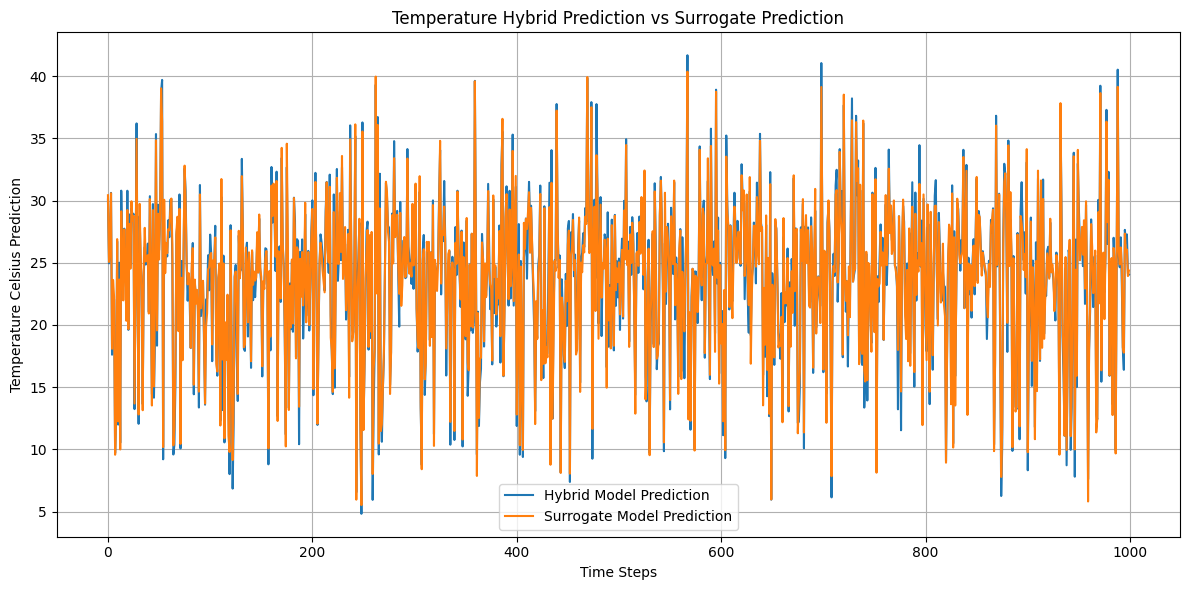

In [39]:
# ============================================================
# 12. Hybrid Prediction vs Surrogate Prediction
# ============================================================

y_surrogate_pred = surrogate_models[final_iteration]["surrogate_pred"]

plot_n = min(1000, len(y_final))

plt.figure(figsize=(12,6))

plt.plot(
    np.array(y_final[:plot_n]),
    label="Hybrid Model Prediction"
)

plt.plot(
    y_surrogate_pred[:plot_n],
    label="Surrogate Model Prediction"
)

plt.title("Temperature Hybrid Prediction vs Surrogate Prediction")
plt.xlabel("Time Steps")
plt.ylabel("Temperature Celsius Prediction")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/11_Temperature_Hybrid_vs_Surrogate_Prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

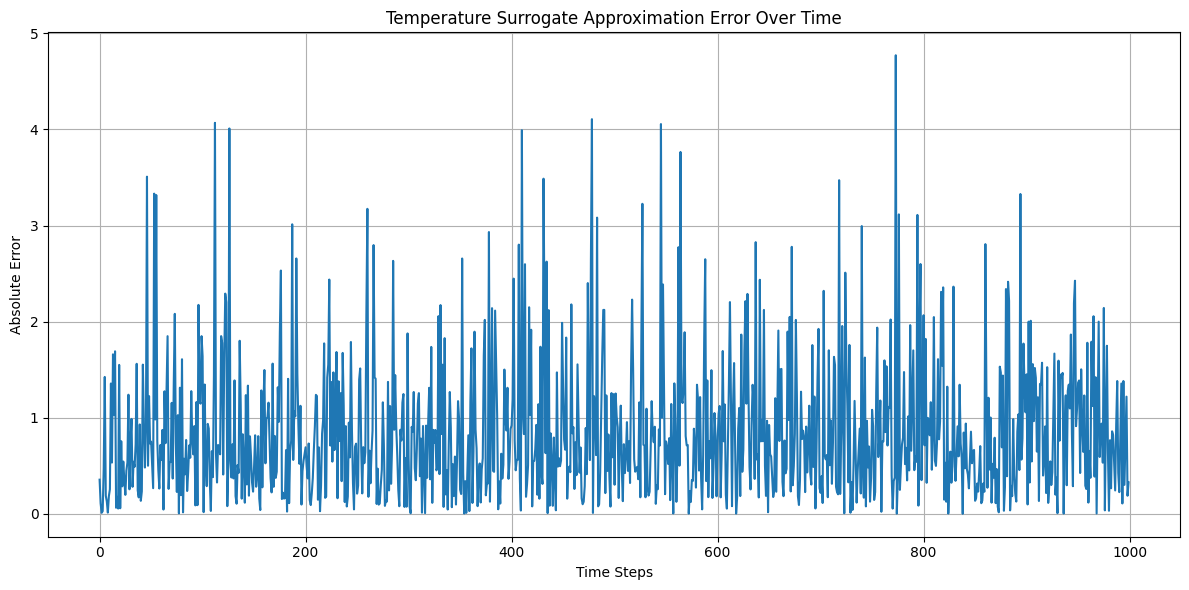

In [40]:
# ============================================================
# 13. Surrogate Error Over Time
# ============================================================

surrogate_error = np.abs(np.array(y_final) - y_surrogate_pred)

plt.figure(figsize=(12,6))

plt.plot(surrogate_error[:plot_n])

plt.title("Temperature Surrogate Approximation Error Over Time")
plt.xlabel("Time Steps")
plt.ylabel("Absolute Error")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/12_Temperature_Surrogate_Error_Over_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [41]:
# ============================================================
# 14. Save Hybrid Iteration Results
# ============================================================

river_results_df.to_csv(
    f"{save_dir}/Temperature_Hybrid_Iteration_Results.csv",
    index=False
)

display(river_results_df)

,Iteration,Model,MSE,RMSE,MAE,R2,Accuracy (%)
0,Iteration 1,River ARF Hybrid,5.299,2.302,1.686,0.905,90.471
1,Iteration 2,River ARF Hybrid,11.949,3.457,2.400,0.887,88.668
2,Iteration 3,River ARF Hybrid,5.479,2.341,1.746,0.899,89.923


In [42]:
# ============================================================
# 15. ZIP and Download All Outputs
# ============================================================

zip_path = "/content/Temperature_Hybrid_Surrogate_XAI_Outputs.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for root, dirs, files_list in os.walk(save_dir):
        for file in files_list:
            file_path = os.path.join(root, file)
            zipf.write(file_path, arcname=file)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>